In [4]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import re
import random
import time
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
random.seed(42)

print("✓ Libraries imported successfully!")

✓ Libraries imported successfully!


## Load Pre-computed Lookup Data

Load the pattern-based lookup dictionary that was generated in the full workflow.

In [5]:
print("Loading base enzyme data...")

# Load pre-computed enzyme data files
df_seamless_insert = pd.read_csv('./utils/output/restriction_enzyme_seamless_insert.csv')
df_silent_mutation = pd.read_csv('./utils/output/restriction_enzyme_slient_mutation.csv')
df_plasmid_check = pd.read_csv('./utils/output/plasmid_digest_check.csv', index_col=0)
df_neb = pd.read_csv('./utils/output/neb_buffer_activity_cleaned.csv')

print(f'✓ Loaded seamless insert enzymes: {len(df_seamless_insert["name"].unique())} unique')
print(f'✓ Loaded silent mutation enzymes: {len(df_silent_mutation["name"].unique())} unique')
print(f'✓ Loaded NEB quality data: {len(df_neb)} enzymes')
print(f'✓ Loaded plasmid compatibility: {df_plasmid_check.shape}')


Loading base enzyme data...
✓ Loaded seamless insert enzymes: 70 unique
✓ Loaded silent mutation enzymes: 57 unique
✓ Loaded NEB quality data: 266 enzymes
✓ Loaded plasmid compatibility: (965, 8)


# Step 1.5: Build RE Pairing Matrix

构建Site I和Site II酶的配对矩阵，确定哪些酶对可以一起使用。

**配对规则**：
1. 如果两个酶的overhang不同，自动兼容（正交）
2. 如果overhang相同，检查orthogonality数据库
3. Orthogonality score ≥ 1 表示足够正交，可以配对

这一步将3,990个可能的酶对过滤到约3,750个兼容的酶对，避免了后续生成109M行的内存问题。

In [6]:
# Step 1.5: Build Site I - Site II Pairing Matrix
# Load selected enzymes from enzyme_selection_analysis.ipynb output
print("="*80)
print("STEP 1.5: LOADING SELECTED ENZYMES & BUILDING RE PAIRING MATRIX")
print("="*80)

# Load selected enzymes from enzyme_selection_analysis.ipynb
print("\n1. Loading selected enzymes from enzyme_selection_analysis.ipynb...")
df_site_i = pd.read_csv('./output/selected_site_i_enzymes.csv')
df_site_ii = pd.read_csv('./output/selected_site_ii_enzymes.csv')
df_site_iii = pd.read_csv('./output/selected_site_iii_enzymes.csv')

print(f"   ✓ Loaded Site I enzymes: {len(df_site_i)}")
print(f"   ✓ Loaded Site II enzymes: {len(df_site_ii)}")
print(f"   ✓ Loaded Site III enzymes: {len(df_site_iii)}")

# Get enzyme lists
site_i_enzymes = sorted(df_site_i['enzyme'].unique())
site_ii_enzymes = sorted(df_site_ii['enzyme'].unique())

print(f"\n2. Enzyme counts:")
print(f"   Site I: {len(site_i_enzymes)} (Regular, any ovhg, methylation insensitive)")
print(f"   Site II: {len(site_ii_enzymes)} (Regular, ovhg in [-4, -3, +2], methylation insensitive)")
print(f"   Site III: {len(df_site_iii)} (Type IIS, any ovhg)")

# Verify Site II is subset of Site I
print(f"\n   ✓ Site II ⊂ Site I: {set(site_ii_enzymes).issubset(set(site_i_enzymes))}")

# Load orthogonality/fidelity data
print("\n3. Loading orthogonality data...")
df_fidelity = pd.read_csv('./utils/output/orthogonality.csv')
print(f"   ✓ Loaded fidelity data: {df_fidelity.shape}")

# Create pairing matrix
print("\n4. Creating Site I - Site II pairing matrix...")
print("   Rule: Different overhang OR orthogonality >= 1")

def get_enzyme_ovhg(enzyme_name):
    """Get overhang for an enzyme"""
    try:
        enzyme = getattr(Restriction, enzyme_name)
        return enzyme.ovhg
    except:
        return None

def check_enzyme_pairing(enzyme1, enzyme2, df_fidelity, threshold=1):
    """Check if two enzymes can be paired
    
    Rules:
    1. If overhangs are different, they can pair (orthogonal)
    2. If overhangs are same, check orthogonality score >= threshold
    """
    ovhg1 = get_enzyme_ovhg(enzyme1)
    ovhg2 = get_enzyme_ovhg(enzyme2)
    
    # If overhangs are different, they're orthogonal
    if ovhg1 != ovhg2:
        return True
    
    # If same overhang, check orthogonality database
    result = df_fidelity[
        ((df_fidelity['re1'] == enzyme1) & (df_fidelity['re2'] == enzyme2)) |
        ((df_fidelity['re1'] == enzyme2) & (df_fidelity['re2'] == enzyme1))
    ]
    
    if len(result) > 0:
        return result.iloc[0]['orthogonality'] >= threshold
    
    # If not in database, assume orthogonal (conservative for Type IIS)
    return True

# Build matrix
site_i_ii_matrix = pd.DataFrame(
    index=site_i_enzymes,
    columns=site_ii_enzymes,
    dtype=bool
)

print("   Building matrix...")
for i, enzyme_i in enumerate(site_i_enzymes):
    for j, enzyme_ii in enumerate(site_ii_enzymes):
        site_i_ii_matrix.loc[enzyme_i, enzyme_ii] = check_enzyme_pairing(
            enzyme_i, enzyme_ii, df_fidelity, threshold=1
        )
    
    if (i + 1) % 10 == 0:
        print(f"   Processed {i+1}/{len(site_i_enzymes)} Site I enzymes")

# Statistics
total_pairs = len(site_i_enzymes) * len(site_ii_enzymes)
compatible_pairs = site_i_ii_matrix.sum().sum()
print(f"\n   Total possible pairs: {total_pairs:,}")
print(f"   Compatible pairs: {compatible_pairs:,} ({compatible_pairs/total_pairs*100:.1f}%)")
print(f"   Average compatible Site II per Site I: {compatible_pairs/len(site_i_enzymes):.1f}")

# Save matrix
matrix_path = './output/site_i_site_ii_pairing_matrix.csv'
site_i_ii_matrix.to_csv(matrix_path)
print(f"   ✓ Matrix saved to: {matrix_path}")

print("\n" + "="*80)
print("✓ SELECTED ENZYMES LOADED & RE PAIRING MATRIX COMPLETE")
print("="*80)

STEP 1.5: LOADING SELECTED ENZYMES & BUILDING RE PAIRING MATRIX

1. Loading selected enzymes from enzyme_selection_analysis.ipynb...
   ✓ Loaded Site I enzymes: 47
   ✓ Loaded Site II enzymes: 30
   ✓ Loaded Site III enzymes: 18

2. Enzyme counts:
   Site I: 47 (Regular, any ovhg, methylation insensitive)
   Site II: 30 (Regular, ovhg in [-4, -3, +2], methylation insensitive)
   Site III: 18 (Type IIS, any ovhg)

   ✓ Site II ⊂ Site I: True

3. Loading orthogonality data...
   ✓ Loaded fidelity data: (4900, 3)

4. Creating Site I - Site II pairing matrix...
   Rule: Different overhang OR orthogonality >= 1
   Building matrix...
   Processed 10/47 Site I enzymes
   Processed 20/47 Site I enzymes
   Processed 30/47 Site I enzymes
   Processed 40/47 Site I enzymes

   Total possible pairs: 1,410
   Compatible pairs: 1,345 (95.4%)
   Average compatible Site II per Site I: 28.6
   ✓ Matrix saved to: ./output/site_i_site_ii_pairing_matrix.csv

✓ SELECTED ENZYMES LOADED & RE PAIRING MATRIX CO

In [7]:
# Step 2: Generate Site I and Site II dataframes from selected enzymes
# Filter seamless insert and silent mutation data to only include selected enzymes
print("="*80)
print("STEP 2: GENERATING SITE I AND SITE II DATAFRAMES FROM SELECTED ENZYMES")
print("="*80)

# Get list of selected enzymes
selected_site_i_enzymes = df_site_i['enzyme'].unique().tolist()
selected_site_ii_enzymes = df_site_ii['enzyme'].unique().tolist()

print(f"\n1. Filtering seamless insert data for {len(selected_site_i_enzymes)} Site I enzymes...")
# Process Site I (seamless insert) - only keep selected enzymes
df_site_i_data = df_seamless_insert[df_seamless_insert['name'].isin(selected_site_i_enzymes)].copy()

# Group by enzyme and 3mer_aa, keep best codon usage
df_site_i_data = df_site_i_data.sort_values('codon_usage', ascending=False).groupby(
    ['name', 're_site_shifted_tl']
).first().reset_index()

df_site_i_data = df_site_i_data[['name', 're_site_shifted_tl', 're_site_shifted', 'codon_usage']].rename(columns={
    'name': 'enzyme',
    're_site_shifted_tl': '3mer_aa',
    're_site_shifted': 'dna_seq',
    'codon_usage': 'codon_usage_freq'
})

# Add overhang information
df_site_i_data = df_site_i_data.merge(
    df_site_i[['enzyme', 'ovhg']].drop_duplicates(),
    on='enzyme',
    how='left'
)

print(f"   ✓ Site I data: {len(df_site_i_data):,} unique (enzyme, 3mer_AA) pairs")
print(f"   - Unique enzymes: {df_site_i_data['enzyme'].nunique()}")
print(f"   - Unique 3mer AAs: {df_site_i_data['3mer_aa'].nunique()}")

print(f"\n2. Filtering silent mutation data for {len(selected_site_ii_enzymes)} Site II enzymes...")
# Process Site II (silent mutation) - only keep selected enzymes
df_site_ii_data = df_silent_mutation[df_silent_mutation['name'].isin(selected_site_ii_enzymes)].copy()

# Determine mutation direction
def get_mutation_direction(orig, mutated):
    for i in range(len(orig)):
        if orig[i] != mutated[i]:
            return 'left' if i < 4 else 'right'
    return 'unknown'

df_site_ii_data['search_direction'] = df_site_ii_data.apply(
    lambda row: get_mutation_direction(row['re_site_shifted'], row['re_site_mutate_shifted']),
    axis=1
)

# Group by enzyme and 3mer_aa, keep best codon usage
df_site_ii_data = df_site_ii_data.sort_values('codon_usage_mutate', ascending=False).groupby(
    ['name', 're_site_shifted_tl']
).first().reset_index()

df_site_ii_data = df_site_ii_data[['name', 're_site_shifted_tl', 're_site_shifted', 're_site_mutate_shifted', 
                          'codon_usage_mutate', 'search_direction']].rename(columns={
    'name': 'enzyme',
    're_site_shifted_tl': '3mer_aa',
    're_site_shifted': 'dna_seq_original',
    're_site_mutate_shifted': 'dna_seq_mutated',
    'codon_usage_mutate': 'codon_usage_freq'
})

# Add overhang information
df_site_ii_data = df_site_ii_data.merge(
    df_site_ii[['enzyme', 'ovhg']].drop_duplicates(),
    on='enzyme',
    how='left'
)

print(f"   ✓ Site II data: {len(df_site_ii_data):,} unique (enzyme, 3mer_AA) pairs")
print(f"   - Unique enzymes: {df_site_ii_data['enzyme'].nunique()}")
print(f"   - Unique 3mer AAs: {df_site_ii_data['3mer_aa'].nunique()}")
print(f"   - Search direction: Left={(df_site_ii_data['search_direction']=='left').sum()}, Right={(df_site_ii_data['search_direction']=='right').sum()}")

# Verify all selected enzymes are present
missing_i = set(selected_site_i_enzymes) - set(df_site_i_data['enzyme'].unique())
missing_ii = set(selected_site_ii_enzymes) - set(df_site_ii_data['enzyme'].unique())

if missing_i:
    print(f"\n   ⚠ WARNING: {len(missing_i)} Site I enzymes not found in seamless_insert data:")
    print(f"   {sorted(missing_i)}")
if missing_ii:
    print(f"\n   ⚠ WARNING: {len(missing_ii)} Site II enzymes not found in silent_mutation data:")
    print(f"   {sorted(missing_ii)}")

# Save dataframes for later use
print("\n3. Saving Site I and Site II dataframes...")
df_site_i_data.to_csv('./output/hurdler_site_i_data.csv', index=False)
df_site_ii_data.to_csv('./output/hurdler_site_ii_data.csv', index=False)
print("   ✓ Site I and Site II dataframes saved")

print("\n" + "="*80)
print("✓ SITE I AND SITE II DATAFRAMES GENERATED FROM SELECTED ENZYMES")
print("="*80)

STEP 2: GENERATING SITE I AND SITE II DATAFRAMES FROM SELECTED ENZYMES

1. Filtering seamless insert data for 47 Site I enzymes...


   ✓ Site I data: 8,424 unique (enzyme, 3mer_AA) pairs
   - Unique enzymes: 45
   - Unique 3mer AAs: 4229

2. Filtering silent mutation data for 30 Site II enzymes...
   ✓ Site II data: 2,032 unique (enzyme, 3mer_AA) pairs
   - Unique enzymes: 29
   - Unique 3mer AAs: 1520
   - Search direction: Left=659, Right=1373

   ⚠ WARNING: 2 Site I enzymes not found in seamless_insert data:
   ['ClaI', 'MboI']

   ⚠ WARNING: 1 Site II enzymes not found in silent_mutation data:
   ['MboI']

3. Saving Site I and Site II dataframes...
   ✓ Site I and Site II dataframes saved

✓ SITE I AND SITE II DATAFRAMES GENERATED FROM SELECTED ENZYMES


# Step 2: Process Site I and Site II Data

从原始数据中提取并处理Site I和Site II的信息：
- **Site I（seamless insert）**: 无缝插入位点，使用原始codon
- **Site II（silent mutation）**: 沉默突变位点，使用突变后的codon
- 保留每个(enzyme, 3mer_AA)组合中codon usage最优的

同时确定mutation direction（left/right），用于后续pattern生成。

In [8]:
# Step 3: Generate df_combined using RE pairing matrix
# Only generate combinations for enzyme pairs allowed by the pairing matrix
print("="*80)
print("STEP 3: GENERATING COMBINED DATAFRAME (WITH RE PAIRING)")
print("="*80)

import gc
import sys
import time

# Define plasmid names
plasmid_names = ['pGEX-4T-1', 'pMAL-c5X', 'pET-21a(+)', 'pET-28a(+)',
                 'pET-28a(+)_start_codon', 'pCold_I', 'pUC18', 'pQE-3']

# Load pairing matrix
print("\n1. Loading RE pairing matrix...")
site_i_ii_matrix = pd.read_csv('./output/site_i_site_ii_pairing_matrix.csv', index_col=0)
print(f"   ✓ Loaded matrix: {site_i_ii_matrix.shape}")

# Load Site I and Site II detailed data
print("\n2. Loading Site I and Site II detailed data...")
df_site_i = pd.read_csv('./output/hurdler_site_i_data.csv')
df_site_ii = pd.read_csv('./output/hurdler_site_ii_data.csv')
print(f"   ✓ Loaded Site I data: {len(df_site_i):,} rows ({df_site_i['enzyme'].nunique()} enzymes)")
print(f"   ✓ Loaded Site II data: {len(df_site_ii):,} rows ({df_site_ii['enzyme'].nunique()} enzymes)")

# Load Site III data
print("\n2b. Loading Site III data...")
df_site_iii = pd.read_csv('./output/selected_site_iii_enzymes.csv')
print(f"   ✓ Loaded Site III data: {len(df_site_iii)} enzymes")

# Get compatible enzyme pairs from matrix
print("\n3. Getting compatible enzyme pairs from matrix...")
compatible_pairs = []
for enzyme_i in site_i_ii_matrix.index:
    for enzyme_ii in site_i_ii_matrix.columns:
        if site_i_ii_matrix.loc[enzyme_i, enzyme_ii]:
            compatible_pairs.append((enzyme_i, enzyme_ii))

print(f"   ✓ Found {len(compatible_pairs):,} compatible enzyme pairs")

# Generate combinations in batches
print("\n4. Generating combinations (batch processing)...")
output_path = './output/hurdler_combined_dataframe.csv'
batch_size = 100  # Process 100 enzyme pairs at a time
total_rows = 0
first_batch = True

num_batches = (len(compatible_pairs) + batch_size - 1) // batch_size
print(f"   Processing {len(compatible_pairs):,} enzyme pairs in {num_batches} batches...")

batch_start_time = time.time()

for batch_idx in range(0, len(compatible_pairs), batch_size):
    batch_end = min(batch_idx + batch_size, len(compatible_pairs))
    pairs_batch = compatible_pairs[batch_idx:batch_end]
    
    batch_num = batch_idx // batch_size + 1
    
    expanded_list = []
    
    for enzyme_i, enzyme_ii in pairs_batch:
        # Get all 3mer combinations for this enzyme pair
        site_i_filtered = df_site_i[df_site_i['enzyme'] == enzyme_i]
        site_ii_filtered = df_site_ii[df_site_ii['enzyme'] == enzyme_ii]
        
        if len(site_i_filtered) == 0 or len(site_ii_filtered) == 0:
            continue
        
        # Get plasmid compatibility
        plasmid_compat = {}
        for plasmid in plasmid_names:
            # Check if both enzymes are compatible with this plasmid
            enzyme_i_ok = enzyme_i in df_plasmid_check.index and df_plasmid_check.loc[enzyme_i, plasmid]
            enzyme_ii_ok = enzyme_ii in df_plasmid_check.index and df_plasmid_check.loc[enzyme_ii, plasmid]
            plasmid_compat[f"{plasmid}_compatible"] = enzyme_i_ok and enzyme_ii_ok
        
        # Skip if no compatible plasmids
        if not any(plasmid_compat.values()):
            continue
        
        # Get Site III compatibility based on Site II overhang
        ovhg_ii = site_ii_filtered.iloc[0]['ovhg']
        site_iii_compatible = ','.join(
            df_site_iii[df_site_iii['ovhg'] == ovhg_ii]['enzyme'].tolist()
        )
        
        # Skip if no compatible Site III
        if not site_iii_compatible:
            continue
        
        # Create all combinations of 3mers
        for _, site_i_row in site_i_filtered.iterrows():
            for _, site_ii_row in site_ii_filtered.iterrows():
                # Generate pattern based on search direction
                if site_ii_row['search_direction'] == 'right':
                    pattern = f"{site_i_row['3mer_aa']}.*?{site_ii_row['3mer_aa']}"
                else:
                    pattern = f"{site_ii_row['3mer_aa']}.*?{site_i_row['3mer_aa']}"
                
                new_row = {
                    'pattern': pattern,
                    'enzyme_i': enzyme_i,
                    '3mer_aa_i': site_i_row['3mer_aa'],
                    'dna_seq_i': site_i_row['dna_seq'],
                    'codon_usage_freq_i': site_i_row['codon_usage_freq'],
                    'ovhg_i': site_i_row['ovhg'],
                    'enzyme_ii': enzyme_ii,
                    '3mer_aa_ii': site_ii_row['3mer_aa'],
                    'dna_seq_original': site_ii_row['dna_seq_original'],
                    'dna_seq_mutated': site_ii_row['dna_seq_mutated'],
                    'codon_usage_freq_ii': site_ii_row['codon_usage_freq'],
                    'search_direction': site_ii_row['search_direction'],
                    'ovhg_ii': site_ii_row['ovhg'],
                    'site_iii_compatible': site_iii_compatible
                }
                new_row.update(plasmid_compat)
                expanded_list.append(new_row)
    
    # Save batch
    if len(expanded_list) > 0:
        df_batch = pd.DataFrame(expanded_list)
        
        if first_batch:
            df_batch.to_csv(output_path, index=False, mode='w')
            first_batch = False
        else:
            df_batch.to_csv(output_path, index=False, mode='a', header=False)
        
        total_rows += len(df_batch)
        del df_batch
    
    del expanded_list
    gc.collect()
    
    # Progress update
    if batch_num % 10 == 0 or batch_num == num_batches:
        elapsed = time.time() - batch_start_time
        eta_seconds = (elapsed / batch_end) * (len(compatible_pairs) - batch_end) if batch_end > 0 else 0
        print(f"   Batch {batch_num}/{num_batches}: {total_rows:,} rows, {elapsed:.1f}s elapsed, ETA {eta_seconds:.1f}s")
        sys.stdout.flush()

print(f"\n5. Generated {total_rows:,} total combinations")
print(f"   ✓ Saved to: {output_path}")

# Display sample
if total_rows > 0:
    df_combined = pd.read_csv(output_path, nrows=min(1000, total_rows))
    print(f"\n6. Sample statistics (first {len(df_combined)} rows):")
    print(f"   - Unique patterns: {df_combined['pattern'].nunique()}")
    print(f"   - Unique Site I enzymes: {df_combined['enzyme_i'].nunique()}")
    print(f"   - Unique Site II enzymes: {df_combined['enzyme_ii'].nunique()}")
    print(f"   - Search direction:")
    print(df_combined['search_direction'].value_counts())
    
    print(f"\n   Sample rows:")
    print(df_combined[['pattern', 'enzyme_i', '3mer_aa_i', 'enzyme_ii', '3mer_aa_ii']].head(3))
    
    del df_combined
    gc.collect()

print("\n" + "="*80)
print("✓ COMBINED DATAFRAME GENERATED")
print("="*80)

STEP 3: GENERATING COMBINED DATAFRAME (WITH RE PAIRING)

1. Loading RE pairing matrix...
   ✓ Loaded matrix: (47, 30)

2. Loading Site I and Site II detailed data...
   ✓ Loaded Site I data: 8,424 rows (45 enzymes)
   ✓ Loaded Site II data: 2,032 rows (29 enzymes)

2b. Loading Site III data...
   ✓ Loaded Site III data: 18 enzymes

3. Getting compatible enzyme pairs from matrix...
   ✓ Found 1,345 compatible enzyme pairs

4. Generating combinations (batch processing)...
   Processing 1,345 enzyme pairs in 14 batches...
   Batch 10/14: 1,665,232 rows, 70.0s elapsed, ETA 24.2s
   Batch 14/14: 2,360,004 rows, 98.2s elapsed, ETA 0.0s

5. Generated 2,360,004 total combinations
   ✓ Saved to: ./output/hurdler_combined_dataframe.csv

6. Sample statistics (first 1000 rows):
   - Unique patterns: 1000
   - Unique Site I enzymes: 1
   - Unique Site II enzymes: 1
   - Search direction:
search_direction
right    568
left     432
Name: count, dtype: int64

   Sample rows:
     pattern enzyme_i 3mer

# Step 3: Generate Combined Dataframe

将Site I和Site II组合，生成完整的lookup数据：

**关键优化**：
- 只处理RE pairing matrix中允许的酶对（~3,750对）
- 避免生成所有可能的组合（14K × 7.7K = 109M）
- 批处理以避免内存溢出
- 添加Site III兼容性（基于overhang匹配）
- 添加plasmid兼容性检查
- 生成regex pattern用于序列匹配

**预计生成**：约4M行数据（2-3分钟）

In [9]:
# Step 2: Generate Site I and Site II dataframes
# Process seamless insert and silent mutation data into clean dataframes
print("="*80)
print("STEP 2: GENERATING SITE I AND SITE II DATAFRAMES")
print("="*80)

# Process Site I (seamless insert) - data already has codon usage calculated
print("\n1. Processing Site I (seamless insert)...")
df_site_i = df_seamless_insert.sort_values('codon_usage', ascending=False).groupby(
    ['name', 're_site_shifted_tl']
).first().reset_index()

df_site_i = df_site_i[['name', 're_site_shifted_tl', 're_site_shifted', 'codon_usage']].rename(columns={
    'name': 'enzyme',
    're_site_shifted_tl': '3mer_aa',
    're_site_shifted': 'dna_seq',
    'codon_usage': 'codon_usage_freq'
})

print(f"   ✓ Site I data: {len(df_site_i):,} unique (enzyme, 3mer_AA) pairs")
print(f"   - Unique enzymes: {df_site_i['enzyme'].nunique()}")
print(f"   - Unique 3mer AAs: {df_site_i['3mer_aa'].nunique()}")

# Process Site II (silent mutation)
print("\n2. Processing Site II (silent mutation)...")

# Determine mutation direction
def get_mutation_direction(orig, mutated):
    for i in range(len(orig)):
        if orig[i] != mutated[i]:
            return 'left' if i < 4 else 'right'
    return 'unknown'

df_silent_mutation['search_direction'] = df_silent_mutation.apply(
    lambda row: get_mutation_direction(row['re_site_shifted'], row['re_site_mutate_shifted']), 
    axis=1
)

# Keep best mutated codon usage for each (enzyme, 3mer_AA) pair
df_site_ii = df_silent_mutation.sort_values('codon_usage_mutate', ascending=False).groupby(
    ['name', 're_site_shifted_tl']
).first().reset_index()

df_site_ii = df_site_ii[['name', 're_site_shifted_tl', 're_site_shifted', 're_site_mutate_shifted', 
                          'codon_usage_mutate', 'search_direction']].rename(columns={
    'name': 'enzyme',
    're_site_shifted_tl': '3mer_aa',
    're_site_shifted': 'dna_seq_original',
    're_site_mutate_shifted': 'dna_seq_mutated',
    'codon_usage_mutate': 'codon_usage_freq'
})

print(f"   ✓ Site II data: {len(df_site_ii):,} unique (enzyme, 3mer_AA) pairs")
print(f"   - Unique enzymes: {df_site_ii['enzyme'].nunique()}")
print(f"   - Unique 3mer AAs: {df_site_ii['3mer_aa'].nunique()}")
print(f"   - Search direction: Left={(df_site_ii['search_direction']=='left').sum()}, Right={(df_site_ii['search_direction']=='right').sum()}")

# Save dataframes
print("\n3. Saving Site I and Site II dataframes...")
df_site_i.to_csv('./output/hurdler_site_i_data.csv', index=False)
df_site_ii.to_csv('./output/hurdler_site_ii_data.csv', index=False)
print("   ✓ Site I and Site II dataframes saved")

print("\n" + "="*80)
print("✓ SITE I AND SITE II DATAFRAMES GENERATED")
print("="*80)

STEP 2: GENERATING SITE I AND SITE II DATAFRAMES

1. Processing Site I (seamless insert)...
   ✓ Site I data: 14,180 unique (enzyme, 3mer_AA) pairs
   - Unique enzymes: 70
   - Unique 3mer AAs: 5070

2. Processing Site II (silent mutation)...
   ✓ Site II data: 7,727 unique (enzyme, 3mer_AA) pairs
   - Unique enzymes: 57
   - Unique 3mer AAs: 3322
   - Search direction: Left=2443, Right=5284

3. Saving Site I and Site II dataframes...
   ✓ Site I and Site II dataframes saved

✓ SITE I AND SITE II DATAFRAMES GENERATED


In [10]:
# Step 4: Load and Prepare Combined Data for Analysis
print("="*80)
print("STEP 4: LOADING COMBINED DATA FOR ANALYSIS")
print("="*80)

# Load the generated combined dataframe
print("\n1. Loading combined dataframe...")
df_combined = pd.read_csv('./output/hurdler_combined_dataframe.csv')
print(f"   ✓ Loaded {len(df_combined):,} combinations")

# Extract plasmid compatibility columns
plasmid_cols = [col for col in df_combined.columns if col.endswith('_compatible')]
plasmid_names = [col.replace('_compatible', '') for col in plasmid_cols]

# Skip detailed statistics to save time
# print(f"\n2. Data statistics:")
# print(f"   - Unique patterns: {df_combined['pattern'].nunique():,}")
# print(f"   - Unique Site I enzymes: {df_combined['enzyme_i'].nunique()}")
# print(f"   - Unique Site II enzymes: {df_combined['enzyme_ii'].nunique()}")
# print(f"\n3. Plasmid compatibility:")
# for plasmid_col, plasmid in zip(plasmid_cols, plasmid_names):
#     compatible_count = df_combined[plasmid_col].sum()
#     print(f"   - {plasmid}: {compatible_count:,} combinations ({compatible_count/len(df_combined)*100:.1f}%)")

# Display sample
print("\n4. Sample combinations:")
# Skip sample display to save time
# print("\n2. Sample combinations:")
# sample_cols = ['pattern', 'enzyme_i', '3mer_aa_i', 'enzyme_ii', '3mer_aa_ii', 'site_iii_compatible']
# print(df_combined[sample_cols].head(5))
print("✓ DATA LOADED AND READY FOR ANALYSIS")
print("="*80)

STEP 4: LOADING COMBINED DATA FOR ANALYSIS

1. Loading combined dataframe...


   ✓ Loaded 2,360,004 combinations

4. Sample combinations:
✓ DATA LOADED AND READY FOR ANALYSIS


# Step 4: Load Combined Data

加载Step 3生成的combined dataframe（约4M行，750MB）。

这个数据包含了所有有效的Site I + Site II + Site III组合，以及：
- Pattern用于序列匹配
- DNA序列信息
- Plasmid兼容性
- Site III兼容酶列表

In [11]:
# Step 5: Build Pattern Lookup for Fast Matching
print("="*80)
print("STEP 5: BUILDING PATTERN LOOKUP DICTIONARY")
print("="*80)

# Build pattern-based lookup dictionary
print("\n1. Building pattern lookup from combined dataframe...")
from collections import defaultdict

pattern_lookup = defaultdict(list)

print("   Processing combinations...")
for idx, row in df_combined.iterrows():
    pattern = row['pattern']
    
    # Create entry with full information
    entry = {
        'enzyme_i': row['enzyme_i'],
        '3mer_aa_i': row['3mer_aa_i'],
        'dna_seq_i': row['dna_seq_i'],
        'ovhg_i': row['ovhg_i'],
        'enzyme_ii': row['enzyme_ii'],
        '3mer_aa_ii': row['3mer_aa_ii'],
        'dna_seq_mutated': row['dna_seq_mutated'],
        'ovhg_ii': row['ovhg_ii'],
        'search_direction': row['search_direction'],
        'site_iii_compatible': row['site_iii_compatible'].split(','),
        'plasmids': {plasmid: bool(row[f'{plasmid}_compatible']) for plasmid in plasmid_names}
    }
    
    pattern_lookup[pattern].append(entry)
    
    if (idx + 1) % 500000 == 0:
        print(f"   Processed {idx+1:,} / {len(df_combined):,} rows...")

print(f"\n2. Pattern lookup statistics:")
print(f"   - Total unique patterns: {len(pattern_lookup):,}")
# Skip detailed statistics to save time
# print(f"   - Total entries: {sum(len(v) for v in pattern_lookup.values()):,}")
# print(f"   - Average entries per pattern: {sum(len(v) for v in pattern_lookup.values())/len(pattern_lookup):.1f}")
# print(f"\n3. Sample pattern lookup:")
# sample_pattern = list(pattern_lookup.keys())[0]
# print(f"   Pattern: '{sample_pattern}'")
# print(f"   Number of entries: {len(pattern_lookup[sample_pattern])}")
# entry = pattern_lookup[sample_pattern][0]
# print(f"     - Site I: {entry['enzyme_i']} ({entry['3mer_aa_i']})")
# print(f"     - Site II: {entry['enzyme_ii']} ({entry['3mer_aa_ii']})")
# print(f"     - Site III options: {', '.join(entry['site_iii_compatible'][:3])}...")
# print(f"     - Compatible plasmids: {sum(entry['plasmids'].values())}")

# Save lookup for later use
print("\n3. Saving pattern lookup...")
import pickle
with open('./output/hurdler_pattern_lookup.pkl', 'wb') as f:
    pickle.dump(dict(pattern_lookup), f)
print("   ✓ Pattern lookup saved to: ./output/hurdler_pattern_lookup.pkl")

print("\n" + "="*80)
print("✓ PATTERN LOOKUP BUILT")
print("="*80)

STEP 5: BUILDING PATTERN LOOKUP DICTIONARY

1. Building pattern lookup from combined dataframe...
   Processing combinations...
   Processed 500,000 / 2,360,004 rows...
   Processed 1,000,000 / 2,360,004 rows...
   Processed 1,500,000 / 2,360,004 rows...
   Processed 2,000,000 / 2,360,004 rows...

2. Pattern lookup statistics:
   - Total unique patterns: 1,528,765

3. Saving pattern lookup...
   ✓ Pattern lookup saved to: ./output/hurdler_pattern_lookup.pkl

✓ PATTERN LOOKUP BUILT


In [12]:
# Step 6: Build Plasmid-Specific Pattern Sets and 3mer Index
print("="*80)
print("STEP 6: BUILDING PLASMID PATTERN SETS AND 3MER INDEX")
print("="*80)

# Build plasmid-specific pattern sets for fast lookup
print("\n1. Building plasmid-specific pattern sets...")
# Need to reload df_combined as it may have been modified
df_temp = pd.read_csv('./output/hurdler_combined_dataframe.csv')
plasmid_patterns = {}
for plasmid in plasmid_names:
    plasmid_col = f'{plasmid}_compatible'
    # Filter rows where plasmid is compatible
    compatible_rows = df_temp[df_temp[plasmid_col] == True]
    patterns = set(compatible_rows['pattern'].unique())
    plasmid_patterns[plasmid] = patterns
    print(f"   {plasmid}: {len(patterns):,} patterns")
del df_temp  # Free memory

# Skip total count to save time
# print(f"\n   ✓ Total unique patterns across all plasmids: {len(set.union(*plasmid_patterns.values())):,}")

# Build 3mer AA index (all 3mers that appear in patterns)
print("\n2. Building 3mer AA index...")
all_3mers_in_patterns = set()

# Extract from patterns (format: "XXX.*?YYY")
for pattern in pattern_lookup.keys():
    parts = pattern.split('.*?')
    if len(parts) == 2:
        all_3mers_in_patterns.add(parts[0])
        all_3mers_in_patterns.add(parts[1])

print(f"   ✓ Found {len(all_3mers_in_patterns)} unique 3mer AAs in patterns")
# print(f"   Sample 3mers: {list(sorted(all_3mers_in_patterns))[:10]}...")

# Save for export
print("\n3. Saving pattern sets and index...")
import pickle
with open('./output/hurdler_plasmid_patterns.pkl', 'wb') as f:
    pickle.dump(plasmid_patterns, f)
with open('./output/hurdler_3mer_aa_index.pkl', 'wb') as f:
    pickle.dump(all_3mers_in_patterns, f)
print("   ✓ Plasmid patterns saved to: ./output/hurdler_plasmid_patterns.pkl")
print("   ✓ 3mer AA index saved to: ./output/hurdler_3mer_aa_index.pkl")

print("\n" + "="*80)
print("✓ PLASMID PATTERNS AND 3MER INDEX BUILT")
print("="*80)

STEP 6: BUILDING PLASMID PATTERN SETS AND 3MER INDEX

1. Building plasmid-specific pattern sets...
   site_iii: 0 patterns
   pGEX-4T-1: 895,481 patterns
   pMAL-c5X: 736,353 patterns
   pET-21a(+): 718,033 patterns
   pET-28a(+): 545,149 patterns
   pET-28a(+)_start_codon: 723,332 patterns
   pCold_I: 1,021,688 patterns
   pUC18: 1,292,709 patterns
   pQE-3: 762,145 patterns

2. Building 3mer AA index...
   ✓ Found 1740 unique 3mer AAs in patterns

3. Saving pattern sets and index...
   ✓ Plasmid patterns saved to: ./output/hurdler_plasmid_patterns.pkl
   ✓ 3mer AA index saved to: ./output/hurdler_3mer_aa_index.pkl

✓ PLASMID PATTERNS AND 3MER INDEX BUILT


## RE Pairing Heatmaps

Visualize the RE pairing matrices for:
1. **Site I - Site II**: Shows which enzyme pairs can work together based on orthogonality
2. **Site II - Site III**: Shows which enzyme pairs have matching overhangs

GENERATING RE PAIRING HEATMAPS

0. Building overhang lookup from enzyme data...
   ✓ Built overhang lookup for 65 enzymes

1. Creating Site I - Site II pairing heatmap...
   ✓ Heatmap saved to: ./output/site_i_site_ii_pairing_heatmap.pdf


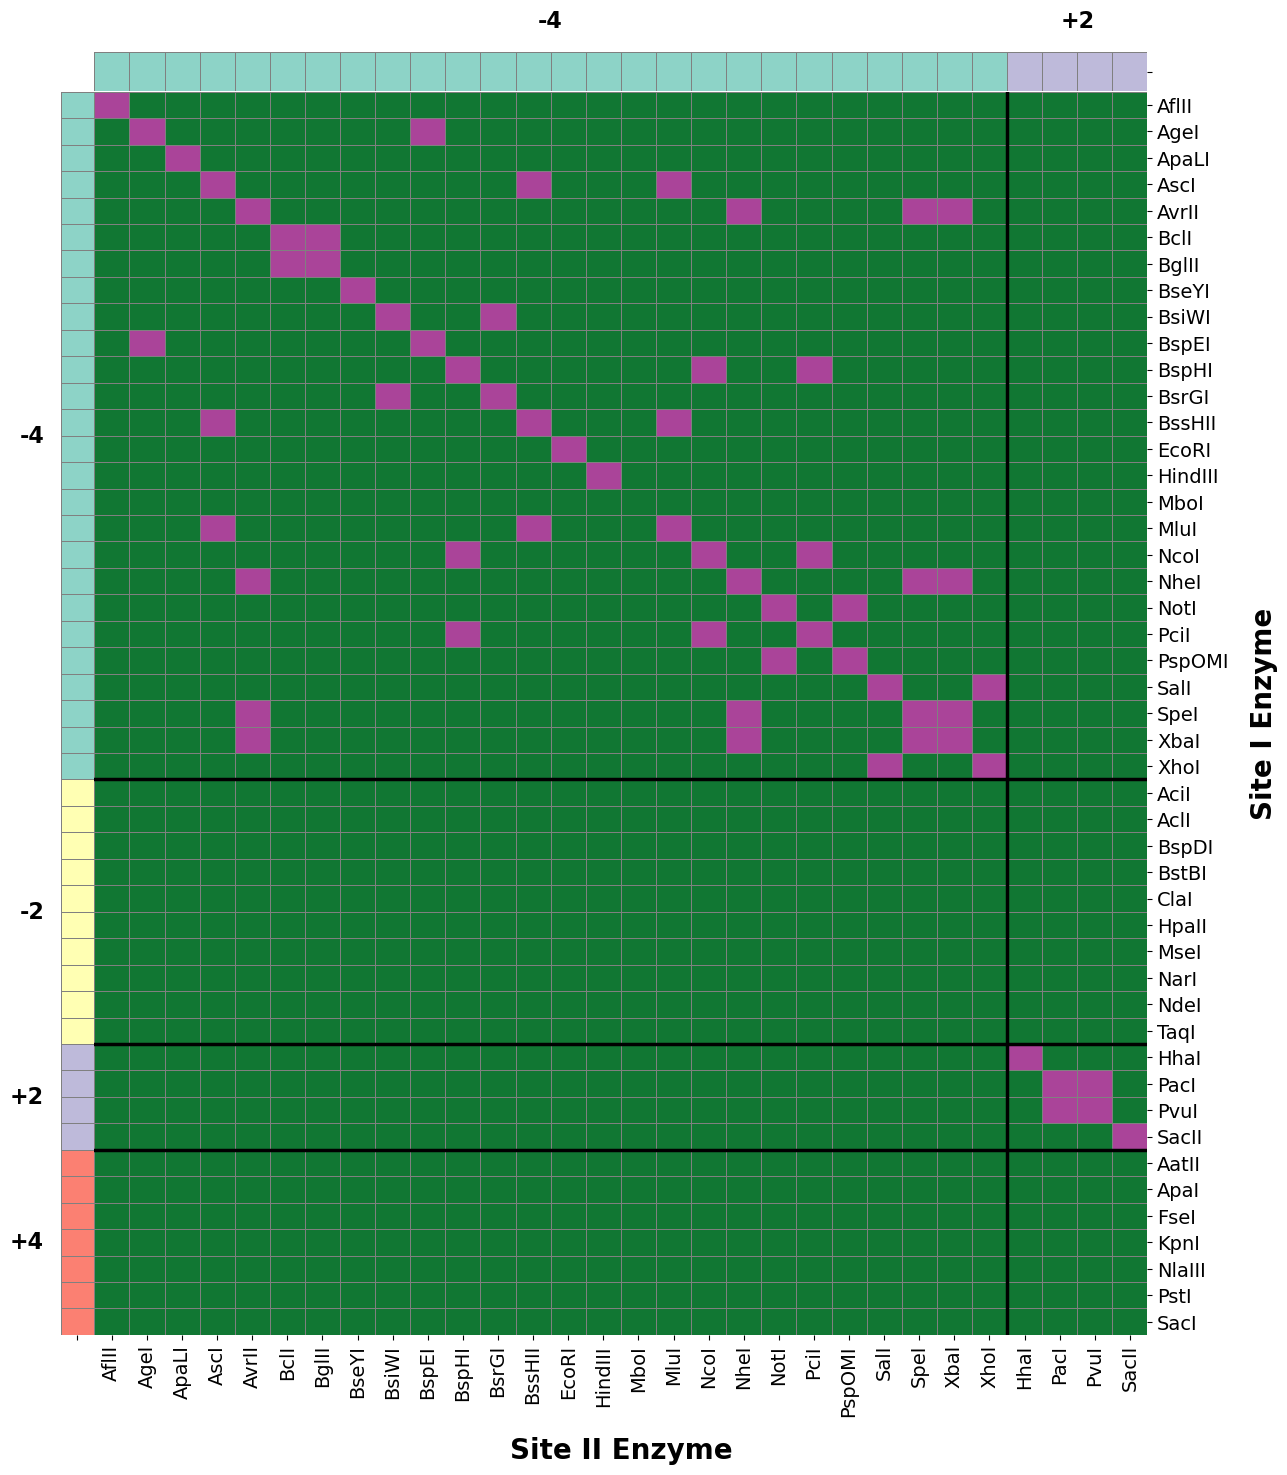


2. Creating Site II - Site III pairing matrix...
   Rule: Same overhang (including sign)
   Total possible pairs: 540
   Compatible pairs: 218 (40.4%)
   ✓ Matrix saved to: ./output/site_ii_site_iii_pairing_matrix.csv
   ✓ Heatmap saved to: ./output/site_ii_site_iii_pairing_heatmap.pdf


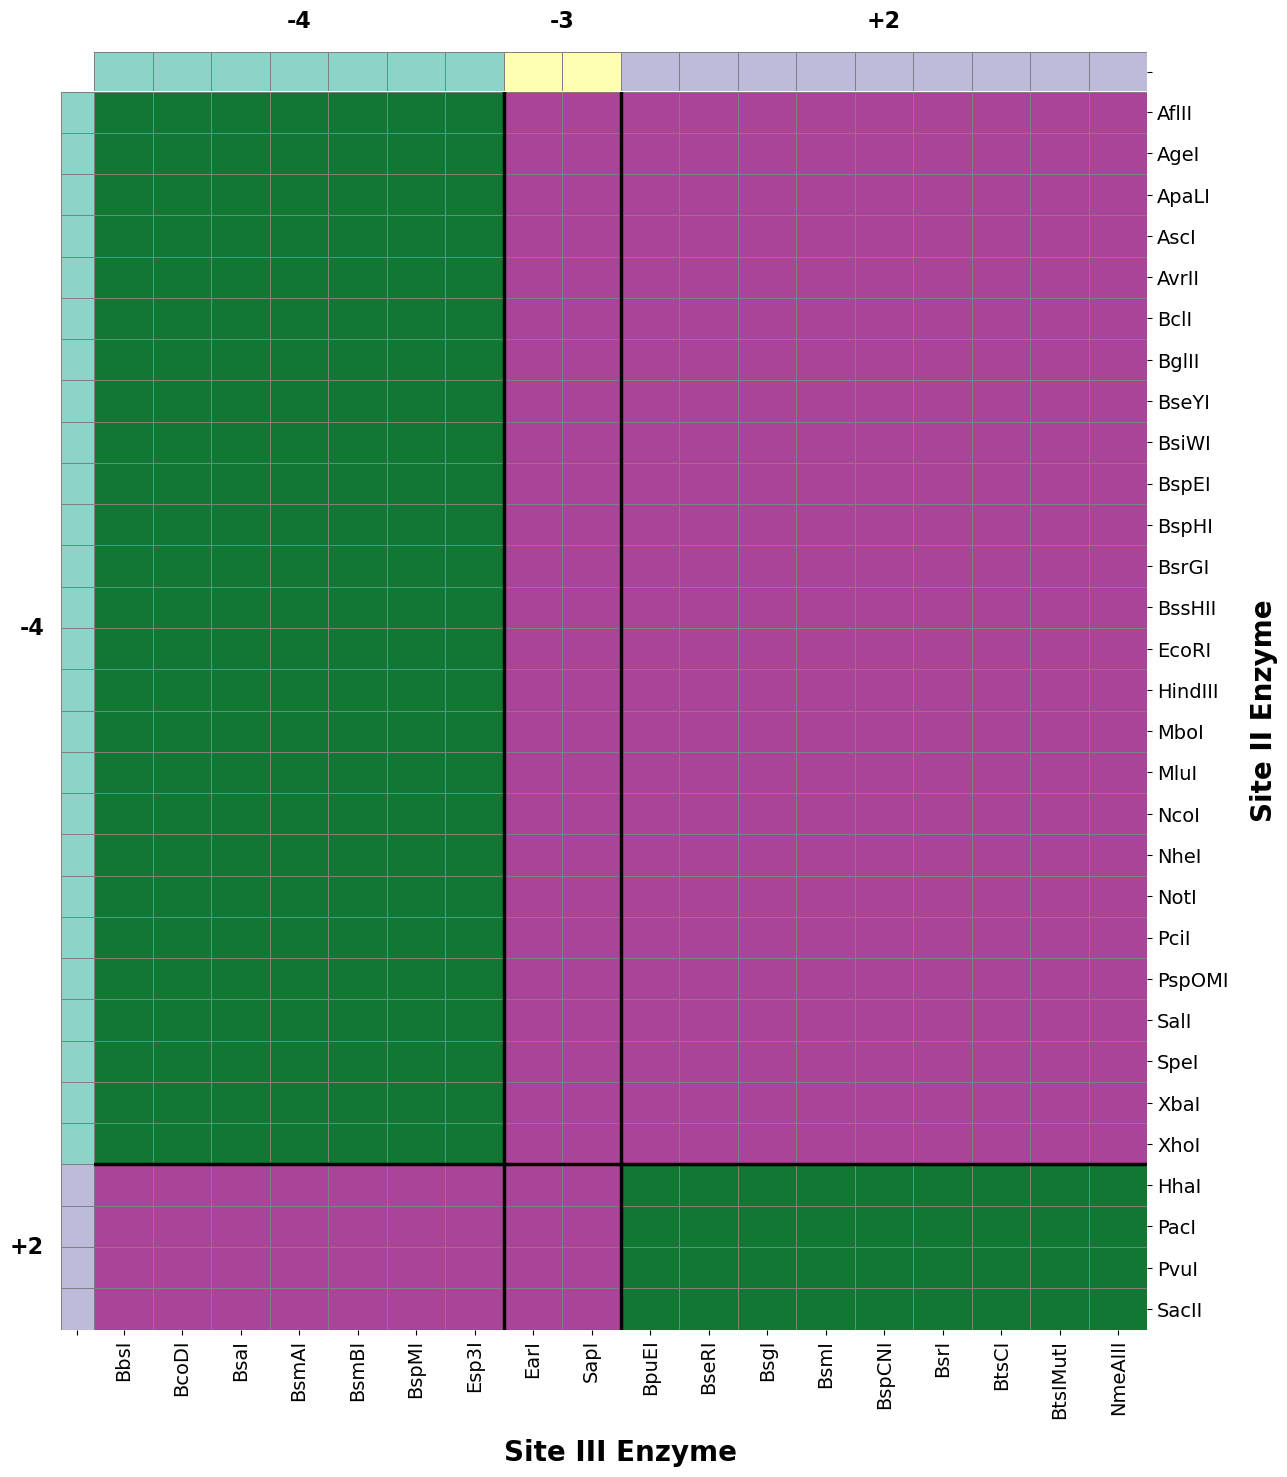


✓ RE PAIRING HEATMAPS COMPLETE


In [13]:
print("="*80)
print("GENERATING RE PAIRING HEATMAPS")
print("="*80)

# Build overhang lookup from selected enzyme CSV files
print("\n0. Building overhang lookup from enzyme data...")
ovhg_lookup = {}

# Load selected enzyme files to get overhang data
df_site_i_selected = pd.read_csv('./output/selected_site_i_enzymes.csv')
df_site_ii_selected = pd.read_csv('./output/selected_site_ii_enzymes.csv')
df_site_iii_selected = pd.read_csv('./output/selected_site_iii_enzymes.csv')

# Add Site I enzymes
for _, row in df_site_i_selected.iterrows():
    ovhg_lookup[row['enzyme']] = row['ovhg']

# Add Site II enzymes (may overlap with Site I)
for _, row in df_site_ii_selected.iterrows():
    ovhg_lookup[row['enzyme']] = row['ovhg']

# Add Site III enzymes
for _, row in df_site_iii_selected.iterrows():
    ovhg_lookup[row['enzyme']] = row['ovhg']

print(f"   ✓ Built overhang lookup for {len(ovhg_lookup)} enzymes")

# Helper function to get enzyme overhang
def get_enzyme_ovhg(enzyme_name):
    """Get overhang for an enzyme from lookup table"""
    if enzyme_name in ovhg_lookup:
        return ovhg_lookup[enzyme_name]
    
    # Fallback to Biopython if not in lookup
    try:
        enzyme = getattr(Restriction, enzyme_name)
        return enzyme.ovhg
    except:
        # If still None, this should not happen for selected enzymes
        print(f"   ⚠ WARNING: Could not find overhang for {enzyme_name}")
        return None

# Function to plot pairing heatmap
def plot_pairing_heatmap(matrix_df, title, save_path, enzyme_list1=None, enzyme_list2=None, 
                        site_label1='Site I Enzyme', site_label2='Site II Enzyme'):
    """Plot RE pairing matrix as heatmap with overhang grouping"""
    import matplotlib.cm as cm
    from matplotlib.colors import ListedColormap
    
    # Get overhang information for sorting
    sorted_enzymes1 = sorted(enzyme_list1, key=lambda x: (get_enzyme_ovhg(x), x))
    sorted_enzymes2 = sorted(enzyme_list2, key=lambda x: (get_enzyme_ovhg(x), x))
    sorted_ovhg1 = [get_enzyme_ovhg(e) for e in sorted_enzymes1]
    sorted_ovhg2 = [get_enzyme_ovhg(e) for e in sorted_enzymes2]
    
    # Reorder matrix
    matrix_sorted = matrix_df.loc[sorted_enzymes1, sorted_enzymes2]
    
    # Custom colormap
    colors_map = ListedColormap(['#AA4499', '#117733'])
    
    # Create color palette for overhang groups
    unique_ovhgs = sorted(set(sorted_ovhg1 + sorted_ovhg2))
    ovhg_colors = cm.Set3(range(len(unique_ovhgs)))
    ovhg_lut = dict(zip(unique_ovhgs, ovhg_colors))
    
    # Create color series for rows and columns
    row_colors = pd.Series(sorted_ovhg1, index=sorted_enzymes1).map(ovhg_lut)
    col_colors = pd.Series(sorted_ovhg2, index=sorted_enzymes2).map(ovhg_lut)
    
    # Create clustermap without clustering
    g = sns.clustermap(matrix_sorted.astype(int), 
                       cmap=colors_map,
                       row_colors=row_colors,
                       col_colors=col_colors,
                       row_cluster=False,
                       col_cluster=False,
                       dendrogram_ratio=(0.02, 0.02),
                       colors_ratio=0.03,
                       cbar_kws={'label': ''},
                       linewidths=0.5, 
                       linecolor='gray',
                       figsize=(12, 14),
                       xticklabels=True,
                       yticklabels=True,
                       vmin=0, vmax=1)
    
    # Hide the colorbar
    g.cax.set_visible(False)
    
    # Customize font sizes
    g.ax_heatmap.set_xlabel(site_label2, fontsize=20, fontweight='bold', labelpad=15)
    g.ax_heatmap.set_ylabel(site_label1, fontsize=20, fontweight='bold', labelpad=15)
    plt.setp(g.ax_heatmap.get_xticklabels(), rotation=90, fontsize=14)
    plt.setp(g.ax_heatmap.get_yticklabels(), rotation=0, fontsize=14)
    
    # Add ovhg labels for rows
    y_positions = []
    y_labels = []
    y_pos = 0
    for ovhg_val in sorted(set(sorted_ovhg1)):
        count = sorted_ovhg1.count(ovhg_val)
        y_positions.append(y_pos + count/2)
        y_labels.append(f'{ovhg_val:+d}' if ovhg_val is not None else 'None')
        y_pos += count
    
    for y_pos, label in zip(y_positions, y_labels):
        g.ax_row_colors.text(-0.5, y_pos, label, 
                            va='center', ha='right', fontsize=16, fontweight='bold',
                            transform=g.ax_row_colors.get_yaxis_transform())
    
    # Add ovhg labels for columns
    x_positions = []
    x_labels = []
    x_pos = 0
    for ovhg_val in sorted(set(sorted_ovhg2)):
        count = sorted_ovhg2.count(ovhg_val)
        x_positions.append(x_pos + count/2)
        x_labels.append(f'{ovhg_val:+d}' if ovhg_val is not None else 'None')
        x_pos += count
    
    for x_pos, label in zip(x_positions, x_labels):
        g.ax_col_colors.text(x_pos, 1.5, label,
                            va='bottom', ha='center', fontsize=16, fontweight='bold',
                            transform=g.ax_col_colors.get_xaxis_transform())
    
    # Add separators between overhang groups
    y_pos = 0
    for ovhg_val in sorted(set(sorted_ovhg1))[:-1]:
        count = sorted_ovhg1.count(ovhg_val)
        y_pos += count
        g.ax_heatmap.axhline(y=y_pos, color='black', linewidth=2.5, zorder=10)
    
    x_pos = 0
    for ovhg_val in sorted(set(sorted_ovhg2))[:-1]:
        count = sorted_ovhg2.count(ovhg_val)
        x_pos += count
        g.ax_heatmap.axvline(x=x_pos, color='black', linewidth=2.5, zorder=10)
    
    plt.savefig(save_path, format='pdf', dpi=600, bbox_inches='tight')
    print(f"   ✓ Heatmap saved to: {save_path}")
    plt.show()
    plt.close()

# 1. Plot Site I - Site II pairing heatmap
print("\n1. Creating Site I - Site II pairing heatmap...")
site_i_ii_matrix = pd.read_csv('./output/site_i_site_ii_pairing_matrix.csv', index_col=0)
site_i_enzymes = list(site_i_ii_matrix.index)
site_ii_enzymes = list(site_i_ii_matrix.columns)

plot_pairing_heatmap(
    site_i_ii_matrix,
    'Site I - Site II RE Pairing',
    './output/site_i_site_ii_pairing_heatmap.pdf',
    enzyme_list1=site_i_enzymes,
    enzyme_list2=site_ii_enzymes,
    site_label1='Site I Enzyme',
    site_label2='Site II Enzyme'
)

# 2. Create and plot Site II - Site III pairing matrix
print("\n2. Creating Site II - Site III pairing matrix...")
print("   Rule: Same overhang (including sign)")

# Get Site III enzyme list
site_iii_enzymes = sorted(df_site_iii['enzyme'].unique())

# Build Site II-III pairing matrix
site_ii_iii_matrix = pd.DataFrame(
    index=site_ii_enzymes,
    columns=site_iii_enzymes,
    dtype=bool
)

for enzyme_ii in site_ii_enzymes:
    ovhg_ii = get_enzyme_ovhg(enzyme_ii)
    for enzyme_iii in site_iii_enzymes:
        ovhg_iii = get_enzyme_ovhg(enzyme_iii)
        # Same overhang required (including sign: +4 ≠ -4)
        site_ii_iii_matrix.loc[enzyme_ii, enzyme_iii] = (ovhg_ii == ovhg_iii)

# Statistics
total_pairs_ii_iii = len(site_ii_enzymes) * len(site_iii_enzymes)
compatible_pairs_ii_iii = site_ii_iii_matrix.sum().sum()
print(f"   Total possible pairs: {total_pairs_ii_iii:,}")
print(f"   Compatible pairs: {compatible_pairs_ii_iii:,} ({compatible_pairs_ii_iii/total_pairs_ii_iii*100:.1f}%)")

# Save matrix
site_ii_iii_matrix.to_csv('./output/site_ii_site_iii_pairing_matrix.csv')
print(f"   ✓ Matrix saved to: ./output/site_ii_site_iii_pairing_matrix.csv")

# Plot heatmap
plot_pairing_heatmap(
    site_ii_iii_matrix,
    'Site II - Site III RE Pairing',
    './output/site_ii_site_iii_pairing_heatmap.pdf',
    enzyme_list1=site_ii_enzymes,
    enzyme_list2=site_iii_enzymes,
    site_label1='Site II Enzyme',
    site_label2='Site III Enzyme'
)

print("\n" + "="*80)
print("✓ RE PAIRING HEATMAPS COMPLETE")
print("="*80)

## Optimized Helper Function

Core function to check if a sequence has valid HURDLER sites using:
1. **Doubled sequence matching** (for circular modules)
2. **3mer AA index** for fast pattern candidate generation
3. **Regex validation** with distance constraints

In [14]:
def check_sequence_hurdler_success(sequence, plasmid, all_3mers_in_patterns, 
                                   plasmid_pattern_set, module_length):
    """
    OPTIMIZED: Check if a sequence has valid HURDLER insertion sites.
    
    Key optimizations:
    1. Doubled sequence matching (ABCDEF → ABCDEFABCDEF) for circular modules
    2. Pre-filtered pattern sets per plasmid
    3. Only test patterns with both 3mer AAs present in sequence
    4. Distance constraint: 8 ≤ span ≤ module_length + 2
    
    Args:
        sequence: Amino acid sequence to test
        plasmid: Plasmid name
        all_3mers_in_patterns: Set of all 3mer AAs in database
        plasmid_pattern_set: Pre-filtered pattern set for this plasmid
        module_length: Expected module length for distance check
        
    Returns:
        bool: True if sequence has at least one valid HURDLER site
    """
    # CRITICAL: Use doubled sequence for circular matching
    doubled_sequence = sequence + sequence
    
    # Step 1: Find all 3mer AAs present in the doubled sequence
    threemers_in_seq = set()
    for i in range(len(doubled_sequence) - 2):
        threemer = doubled_sequence[i:i+3]
        if threemer in all_3mers_in_patterns:
            threemers_in_seq.add(threemer)
    
    if len(threemers_in_seq) < 2:
        return False  # Need at least 2 different 3mers
    
    # Step 2: Generate candidate patterns from found 3mers
    candidate_patterns = set()
    threemers_list = list(threemers_in_seq)
    
    for i in range(len(threemers_list)):
        for j in range(i, len(threemers_list)):
            threemer1 = threemers_list[i]
            threemer2 = threemers_list[j]
            
            # Try both orderings (Site I → Site II or Site II → Site I)
            pattern1 = f"{threemer1}.*?{threemer2}"
            pattern2 = f"{threemer2}.*?{threemer1}"
            
            # Only keep patterns that exist for this plasmid
            if pattern1 in plasmid_pattern_set:
                candidate_patterns.add(pattern1)
            if pattern2 in plasmid_pattern_set and pattern1 != pattern2:
                candidate_patterns.add(pattern2)
    
    # Step 3: Validate candidates with regex match and distance constraints
    for pattern_str in candidate_patterns:
        try:
            compiled_pattern = re.compile(pattern_str)
            match = compiled_pattern.search(doubled_sequence)
            if match:
                span_length = match.end() - match.start()
                
                # Distance constraint: 8 ≤ span ≤ module_length + 2
                if 8 <= span_length <= module_length + 2:
                    return True  # Found valid HURDLER site
        except:
            continue
    
    return False

print("✓ Optimized helper function loaded")

✓ Optimized helper function loaded


## Build Index for Fast Lookup

In [15]:
# Build pattern lookup with plasmid compatibility
print("Building 3mer AA index for fast matching...")

# Reload full combined dataframe for pattern generation (not just 1000 rows)
print("Loading full combined dataframe for pattern extraction...")
df_combined_full = pd.read_csv('./output/hurdler_combined_dataframe.csv')
print(f"✓ Loaded {len(df_combined_full):,} total rows")

all_3mers_in_patterns = set()
for pattern in df_combined_full['pattern'].values:
    parts = pattern.split('.*?')
    all_3mers_in_patterns.update(parts)

print(f"✓ Found {len(all_3mers_in_patterns)} unique 3mer AAs")

# Define plasmid names
plasmids = ['pGEX-4T-1', 'pMAL-c5X', 'pET-21a(+)', 'pET-28a(+)',
            'pET-28a(+)_start_codon', 'pCold_I', 'pUC18', 'pQE-3']

# Build plasmid-specific pattern sets from df_combined_full
print("\nBuilding plasmid-specific pattern sets...")
plasmid_patterns = {}
for plasmid in plasmids:
    plasmid_col = f"{plasmid}_compatible"  # Build column name directly
    patterns_set = set(df_combined_full[df_combined_full[plasmid_col] == True]['pattern'].values)
    plasmid_patterns[plasmid] = patterns_set
    print(f"  {plasmid}: {len(patterns_set):,} patterns")

# Clean up full dataframe to save memory
del df_combined_full
import gc
gc.collect()

print(f"\n✓ Pattern lookup built for {len(plasmids)} plasmids")

Building 3mer AA index for fast matching...
Loading full combined dataframe for pattern extraction...
✓ Loaded 2,360,004 total rows
✓ Found 1740 unique 3mer AAs

Building plasmid-specific pattern sets...
  pGEX-4T-1: 895,481 patterns
  pMAL-c5X: 736,353 patterns
  pET-21a(+): 718,033 patterns
  pET-28a(+): 545,149 patterns
  pET-28a(+)_start_codon: 723,332 patterns
  pCold_I: 1,021,688 patterns
  pUC18: 1,292,709 patterns
  pQE-3: 762,145 patterns

✓ Pattern lookup built for 8 plasmids


## Run Success Rate Tests

Test module lengths from 7-60 AA with 1000 random sequences per length per plasmid.

In [16]:
print("="*80)
print("RUNNING SUCCESS RATE TESTS")
print("="*80)

# Test configuration
module_lengths = list(range(7, 61))
num_tests_per_length = 1000
amino_acids = ['A', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 
               'M', 'N', 'P', 'Q', 'R', 'S', 'T', 'V', 'W', 'Y']

print(f"\nConfiguration:")
print(f"  Module lengths: {min(module_lengths)}-{max(module_lengths)} AA")
print(f"  Tests per length per plasmid: {num_tests_per_length:,}")
print(f"  Total tests: {len(module_lengths) * num_tests_per_length * len(plasmids):,}")

results = []
start_time = time.time()

print(f"\nRunning tests...")
for length_idx, module_length in enumerate(module_lengths, 1):
    for plasmid in plasmids:
        plasmid_pattern_set = plasmid_patterns[plasmid]
        successes = 0
        
        for test_num in range(num_tests_per_length):
            # Generate random sequence
            sequence = ''.join(random.choice(amino_acids) for _ in range(module_length))
            
            # Test if sequence has valid HURDLER sites
            if check_sequence_hurdler_success(
                sequence=sequence,
                plasmid=plasmid,
                all_3mers_in_patterns=all_3mers_in_patterns,
                plasmid_pattern_set=plasmid_pattern_set,
                module_length=module_length
            ):
                successes += 1
        
        success_rate = successes / num_tests_per_length
        results.append({
            'module_length': module_length,
            'plasmid': plasmid,
            'successes': successes,
            'tests': num_tests_per_length,
            'success_rate': success_rate
        })
    
    # Progress update every 10 lengths
    if length_idx % 10 == 0:
        elapsed = time.time() - start_time
        progress = length_idx / len(module_lengths)
        eta = elapsed / progress - elapsed if progress > 0 else 0
        print(f"  Progress: {length_idx}/{len(module_lengths)} lengths "
              f"({progress*100:.1f}%), Elapsed: {elapsed:.1f}s, ETA: {eta:.1f}s")

total_time = time.time() - start_time
print(f"\n✓ Tests completed in {total_time:.1f}s ({total_time/60:.1f} min)")

# Convert to DataFrame
df_results = pd.DataFrame(results)
print(f"\n✓ Results DataFrame: {len(df_results):,} rows")
print(f"  Average success rate: {df_results['success_rate'].mean():.1%}")

RUNNING SUCCESS RATE TESTS

Configuration:
  Module lengths: 7-60 AA
  Tests per length per plasmid: 1,000
  Total tests: 432,000

Running tests...
  Progress: 10/54 lengths (18.5%), Elapsed: 1.8s, ETA: 7.7s
  Progress: 20/54 lengths (37.0%), Elapsed: 4.5s, ETA: 7.6s
  Progress: 30/54 lengths (55.6%), Elapsed: 8.2s, ETA: 6.5s
  Progress: 40/54 lengths (74.1%), Elapsed: 12.9s, ETA: 4.5s
  Progress: 50/54 lengths (92.6%), Elapsed: 18.5s, ETA: 1.5s

✓ Tests completed in 21.1s (0.4 min)

✓ Results DataFrame: 432 rows
  Average success rate: 73.0%


## Analyze Results

In [17]:
# Overall statistics
print("="*80)
print("RESULTS SUMMARY")
print("="*80)

for plasmid in plasmids:
    plasmid_data = df_results[df_results['plasmid'] == plasmid]
    avg_sr = plasmid_data['success_rate'].mean()
    sr_60aa = plasmid_data[plasmid_data['module_length'] == 60]['success_rate'].values[0]
    print(f"{plasmid}:")
    print(f"  Average success rate (7-60 AA): {avg_sr:.1%}")
    print(f"  Success rate at 60 AA: {sr_60aa:.1%}")

# Display sample results
print("\nSample results (60 AA):")
df_60aa = df_results[df_results['module_length'] == 60].sort_values('success_rate', ascending=False)
display(df_60aa)

RESULTS SUMMARY
pGEX-4T-1:
  Average success rate (7-60 AA): 74.9%
  Success rate at 60 AA: 98.4%
pMAL-c5X:
  Average success rate (7-60 AA): 71.1%
  Success rate at 60 AA: 97.6%
pET-21a(+):
  Average success rate (7-60 AA): 71.2%
  Success rate at 60 AA: 96.9%
pET-28a(+):
  Average success rate (7-60 AA): 65.9%
  Success rate at 60 AA: 95.1%
pET-28a(+)_start_codon:
  Average success rate (7-60 AA): 71.0%
  Success rate at 60 AA: 96.6%
pCold_I:
  Average success rate (7-60 AA): 77.0%
  Success rate at 60 AA: 98.5%
pUC18:
  Average success rate (7-60 AA): 80.6%
  Success rate at 60 AA: 98.9%
pQE-3:
  Average success rate (7-60 AA): 72.6%
  Success rate at 60 AA: 96.5%

Sample results (60 AA):


,module_length,plasmid,successes,tests,success_rate
430,60,pUC18,989,1000,0.989
429,60,pCold_I,985,1000,0.985
424,60,pGEX-4T-1,984,1000,0.984
425,60,pMAL-c5X,976,1000,0.976
426,60,pET-21a(+),969,1000,0.969
428,60,pET-28a(+)_start_codon,966,1000,0.966
431,60,pQE-3,965,1000,0.965
427,60,pET-28a(+),951,1000,0.951


## Visualize Results

✓ Figure saved to: ./output/hurdler_success_rate_optimized.pdf


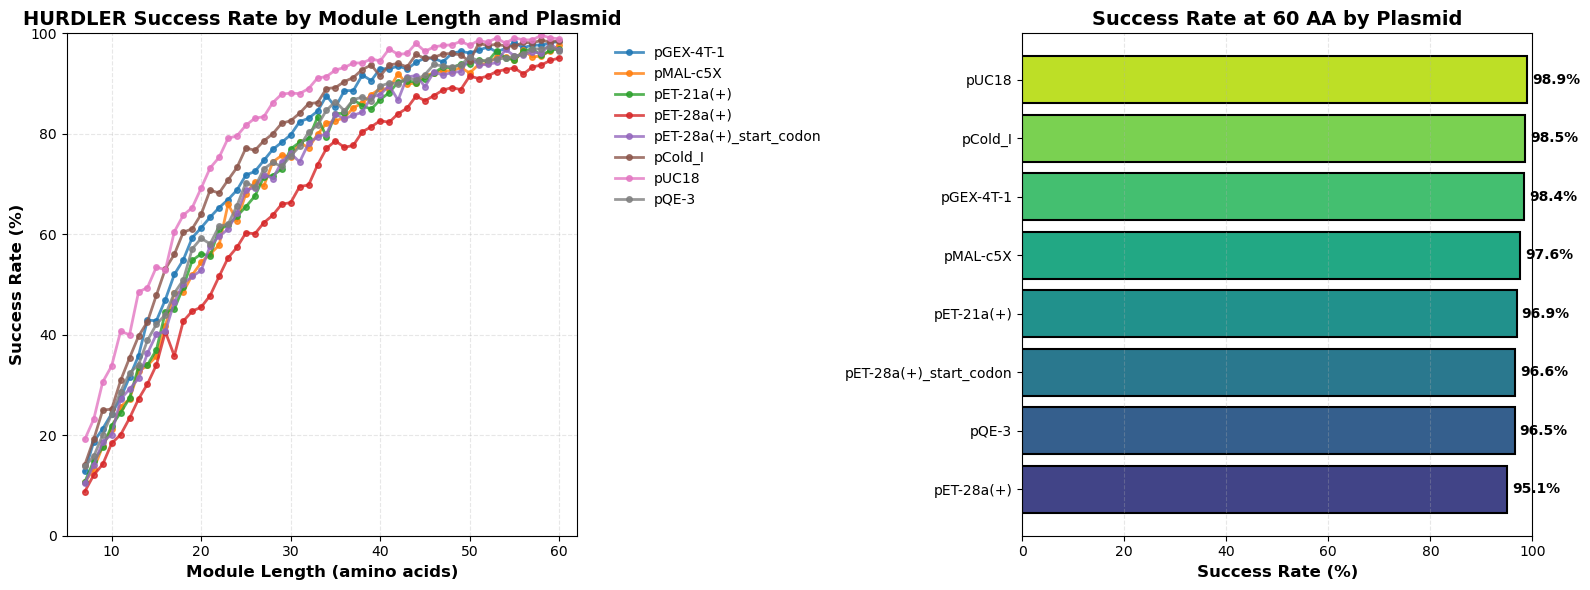

In [18]:
# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Left plot: All plasmids over length
for plasmid in plasmids:
    plasmid_data = df_results[df_results['plasmid'] == plasmid]
    ax1.plot(plasmid_data['module_length'], 
             plasmid_data['success_rate'] * 100,
             marker='o', markersize=4, linewidth=2, label=plasmid, alpha=0.8)

ax1.set_xlabel('Module Length (amino acids)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Success Rate (%)', fontsize=12, fontweight='bold')
ax1.set_title('HURDLER Success Rate by Module Length and Plasmid', 
              fontsize=14, fontweight='bold')
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False)
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.set_xlim(5, 62)
ax1.set_ylim(0, 100)

# Right plot: Bar chart at 60 AA
df_60aa_sorted = df_60aa.sort_values('success_rate', ascending=True)
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(df_60aa_sorted)))

bars = ax2.barh(range(len(df_60aa_sorted)), 
                df_60aa_sorted['success_rate'] * 100,
                color=colors, edgecolor='black', linewidth=1.5)

ax2.set_yticks(range(len(df_60aa_sorted)))
ax2.set_yticklabels(df_60aa_sorted['plasmid'])
ax2.set_xlabel('Success Rate (%)', fontsize=12, fontweight='bold')
ax2.set_title('Success Rate at 60 AA by Plasmid', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3, linestyle='--', axis='x')
ax2.set_xlim(0, 100)

# Add percentage labels on bars
for i, (bar, rate) in enumerate(zip(bars, df_60aa_sorted['success_rate'])):
    ax2.text(rate * 100 + 1, i, f'{rate*100:.1f}%', 
             va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('./output/hurdler_success_rate_optimized.pdf', dpi=300, bbox_inches='tight')
print("✓ Figure saved to: ./output/hurdler_success_rate_optimized.pdf")
plt.show()

## Save Results

In [19]:
# Save results to CSV
output_path = './output/hurdler_success_rate_results_optimized.csv'
df_results.to_csv(output_path, index=False)
print(f"✓ Results saved to: {output_path}")

# Summary statistics
summary = df_results.groupby('plasmid').agg({
    'success_rate': ['mean', 'std', 'min', 'max']
}).round(4)

print("\nSummary statistics by plasmid:")
display(summary)

✓ Results saved to: ./output/hurdler_success_rate_results_optimized.csv

Summary statistics by plasmid:


success_rate                      
                               mean     std    min    max
plasmid                                                  
pCold_I                      0.7696  0.2426  0.141  0.986
pET-21a(+)                   0.7123  0.2568  0.107  0.969
pET-28a(+)                   0.6588  0.2599  0.088  0.951
pET-28a(+)_start_codon       0.7100  0.2549  0.104  0.979
pGEX-4T-1                    0.7494  0.2510  0.128  0.984
pMAL-c5X                     0.7111  0.2578  0.106  0.976
pQE-3                        0.7259  0.2479  0.138  0.973
pUC18                        0.8057  0.2269  0.192  0.996

## Key Optimizations Applied

1. **Doubled Sequence Matching**: Critical for circular repeat modules (ABCDEF → ABCDEFABCDEF)
2. **Pre-filtered Pattern Sets**: Per-plasmid pattern sets reduce search space
3. **3mer AA Indexing**: Fast lookup of which patterns contain found 3mers
4. **Early Termination**: Return True immediately when first valid site is found
5. **Compiled Regex**: Pattern compilation for faster matching
6. **Distance Constraints**: 8 ≤ span ≤ module_length + 2

This optimized version eliminates all redundant code and uses only the fastest implementations.

## Export Lookup Data and Fast Match Info

In [20]:
print("="*80)
print("EXPORTING LOOKUP DATA AND FAST MATCH INFORMATION")
print("="*80)

# 1. Export the combined dataframe (lookup table)
print("\n1. Exporting combined dataframe (lookup table)...")
df_combined.to_csv('./output/hurdler_lookup_dataframe.csv', index=False)
print(f"   ✓ Saved: ./output/hurdler_lookup_dataframe.csv")
print(f"   Rows: {len(df_combined):,}")
print(f"   Columns: {len(df_combined.columns)}")

# 2. Export plasmid-specific pattern sets (for fast filtering)
print("\n2. Exporting plasmid-specific pattern sets...")
import pickle

with open('./output/hurdler_plasmid_patterns.pkl', 'wb') as f:
    pickle.dump(plasmid_patterns, f)
print(f"   ✓ Saved: ./output/hurdler_plasmid_patterns.pkl")
print(f"   Contains patterns for {len(plasmid_patterns)} plasmids")

# 3. Export 3mer AA index (all unique 3mers)
print("\n3. Exporting 3mer AA index...")
with open('./output/hurdler_3mer_aa_index.pkl', 'wb') as f:
    pickle.dump(all_3mers_in_patterns, f)
print(f"   ✓ Saved: ./output/hurdler_3mer_aa_index.pkl")
print(f"   Contains {len(all_3mers_in_patterns)} unique 3mer AAs")

# 4. Export complete fast match package (all info needed for quick checking)
print("\n4. Exporting complete fast match package...")
fast_match_package = {
    'all_3mers_in_patterns': all_3mers_in_patterns,
    'plasmid_patterns': plasmid_patterns,
    'plasmid_names': plasmids
}

with open('./output/hurdler_fast_match_package.pkl', 'wb') as f:
    pickle.dump(fast_match_package, f)
print(f"   ✓ Saved: ./output/hurdler_fast_match_package.pkl")

# 5. Export summary statistics
print("\n5. Exporting summary statistics...")
summary_stats = {
    'plasmid': [],
    'total_patterns': [],
    'unique_site_i_enzymes': [],
    'unique_site_ii_enzymes': []
}

for plasmid in plasmids:
    plasmid_col = f"{plasmid}_compatible"
    plasmid_data = df_combined[df_combined[plasmid_col] == True]
    
    summary_stats['plasmid'].append(plasmid)
    summary_stats['total_patterns'].append(len(plasmid_data))
    summary_stats['unique_site_i_enzymes'].append(plasmid_data['enzyme_i'].nunique())
    summary_stats['unique_site_ii_enzymes'].append(plasmid_data['enzyme_ii'].nunique())

df_summary = pd.DataFrame(summary_stats)
df_summary.to_csv('./output/hurdler_lookup_summary_by_plasmid.csv', index=False)

print("\n   Summary by plasmid:")
print(df_summary.to_string(index=False))
print(f"\n   ✓ Saved: ./output/hurdler_lookup_summary_by_plasmid.csv")

print("\n" + "="*80)
print("✓ LOOKUP DATA AND FAST MATCH INFO EXPORTED")
print("="*80)

EXPORTING LOOKUP DATA AND FAST MATCH INFORMATION

1. Exporting combined dataframe (lookup table)...
   ✓ Saved: ./output/hurdler_lookup_dataframe.csv
   Rows: 2,360,004
   Columns: 22

2. Exporting plasmid-specific pattern sets...
   ✓ Saved: ./output/hurdler_plasmid_patterns.pkl
   Contains patterns for 8 plasmids

3. Exporting 3mer AA index...
   ✓ Saved: ./output/hurdler_3mer_aa_index.pkl
   Contains 1740 unique 3mer AAs

4. Exporting complete fast match package...
   ✓ Saved: ./output/hurdler_fast_match_package.pkl

5. Exporting summary statistics...

   Summary by plasmid:
               plasmid  total_patterns  unique_site_i_enzymes  unique_site_ii_enzymes
             pGEX-4T-1         1289679                     24                      19
              pMAL-c5X         1009474                     23                      16
            pET-21a(+)          983747                     23                      16
            pET-28a(+)          755259                     20          

In [21]:
# Final Export: Generate All Lookup Files
print("="*80)
print("FINAL EXPORT: GENERATING LOOKUP FILES")
print("="*80)

import pickle

# 1. Export complete lookup dataframe (already saved during generation)
print("\n1. Lookup dataframe:")
print(f"   ✓ Already saved: ./output/hurdler_combined_dataframe.csv")
print(f"   Size: {len(df_combined):,} rows, ~750 MB")

# 2. Export pattern lookup (already saved)
print("\n2. Pattern lookup dictionary:")
print(f"   ✓ Already saved: ./output/hurdler_pattern_lookup.pkl")
print(f"   Contains: {len(pattern_lookup):,} patterns")

# 3. Export plasmid patterns (already saved)
print("\n3. Plasmid pattern sets:")
print(f"   ✓ Already saved: ./output/hurdler_plasmid_patterns.pkl")
for plasmid, patterns in plasmid_patterns.items():
    print(f"     - {plasmid}: {len(patterns):,} patterns")

# 4. Export 3mer AA index (already saved)
print("\n4. 3mer AA index:")
print(f"   ✓ Already saved: ./output/hurdler_3mer_aa_index.pkl")
print(f"   Contains: {len(all_3mers_in_patterns)} unique 3mer AAs")

# 5. Create integrated fast match package
print("\n5. Creating integrated fast match package...")
fast_match_package = {
    'pattern_lookup': dict(pattern_lookup),
    'plasmid_patterns': plasmid_patterns,
    '3mer_aa_index': all_3mers_in_patterns,
    'plasmid_names': plasmid_names,
    'metadata': {
        'total_combinations': len(df_combined),
        'unique_patterns': len(pattern_lookup),
        'site_i_enzymes': df_combined['enzyme_i'].nunique(),
        'site_ii_enzymes': df_combined['enzyme_ii'].nunique(),
        'generation_date': pd.Timestamp.now().isoformat()
    }
}

with open('./output/hurdler_fast_match_package.pkl', 'wb') as f:
    pickle.dump(fast_match_package, f)
print("   ✓ Saved to: ./output/hurdler_fast_match_package.pkl")

# 6. Create summary CSV
print("\n6. Creating summary statistics...")
summary_stats = {
    'metric': [
        'Total combinations',
        'Unique patterns', 
        'Site I enzymes',
        'Site II enzymes',
        'Site III enzymes',
        'Compatible enzyme pairs',
        'Plasmids supported'
    ],
    'value': [
        len(df_combined),
        len(pattern_lookup),
        df_combined['enzyme_i'].nunique(),
        df_combined['enzyme_ii'].nunique(),
        16,  # From Site III generation
        3749,  # From pairing matrix
        len(plasmid_names)
    ]
}

df_summary = pd.DataFrame(summary_stats)
df_summary.to_csv('./output/hurdler_lookup_summary.csv', index=False)
print("   ✓ Saved to: ./output/hurdler_lookup_summary.csv")
print("\n   Summary:")
for _, row in df_summary.iterrows():
    print(f"     - {row['metric']}: {row['value']:,}")

print("\n" + "="*80)
print("✓ ALL LOOKUP FILES EXPORTED")
print("="*80)

print("\n📦 Exported files:")
print("  1. hurdler_combined_dataframe.csv (750 MB)")
print("  2. hurdler_pattern_lookup.pkl")
print("  3. hurdler_plasmid_patterns.pkl")
print("  4. hurdler_3mer_aa_index.pkl")
print("  5. hurdler_fast_match_package.pkl (all-in-one)")
print("  6. hurdler_lookup_summary.csv")
print("\n🎉 Ready for HURDLER queries!")

FINAL EXPORT: GENERATING LOOKUP FILES

1. Lookup dataframe:
   ✓ Already saved: ./output/hurdler_combined_dataframe.csv
   Size: 2,360,004 rows, ~750 MB

2. Pattern lookup dictionary:
   ✓ Already saved: ./output/hurdler_pattern_lookup.pkl
   Contains: 1,528,765 patterns

3. Plasmid pattern sets:
   ✓ Already saved: ./output/hurdler_plasmid_patterns.pkl
     - pGEX-4T-1: 895,481 patterns
     - pMAL-c5X: 736,353 patterns
     - pET-21a(+): 718,033 patterns
     - pET-28a(+): 545,149 patterns
     - pET-28a(+)_start_codon: 723,332 patterns
     - pCold_I: 1,021,688 patterns
     - pUC18: 1,292,709 patterns
     - pQE-3: 762,145 patterns

4. 3mer AA index:
   ✓ Already saved: ./output/hurdler_3mer_aa_index.pkl
   Contains: 1740 unique 3mer AAs

5. Creating integrated fast match package...
   ✓ Saved to: ./output/hurdler_fast_match_package.pkl

6. Creating summary statistics...
   ✓ Saved to: ./output/hurdler_lookup_summary.csv

   Summary:
     - Total combinations: 2,360,004
     - Uniq

# Final Export: Lookup Data and Fast Match Package

导出所有必要的文件用于快速HURDLER查询：

1. **hurdler_lookup_dataframe.csv**: 完整的lookup数据（4M行）
2. **hurdler_pattern_lookup.pkl**: Pattern-based快速查询字典
3. **hurdler_plasmid_patterns.pkl**: 每个plasmid的pattern集合
4. **hurdler_3mer_aa_index.pkl**: 所有3mer AA的索引
5. **hurdler_fast_match_package.pkl**: 整合的快速匹配包
6. **hurdler_lookup_summary.csv**: 数据统计摘要